# PetFinder.my — прогноз швидкості адопції (фінальний проєкт)

**Задача.** За фото та текстовим описом тварини передбачити порядкову категорію швидкості адопції (1 — найшвидше, 4 — найповільніше). Метрика — quadratic weighted kappa (QWK).

**Підхід (коротко).**
1. Фото → заморожені енкодери **CLIP ViT-L/14** і **SigLIP2 SO400M** → ембедінги всіх фото тварини → агрегація (mean, перше фото).
2. Текст → TF-IDF (слова + символи) і текстовий енкодер CLIP → ембедінги; regex-ознаки (вік, тип, кількість тварин тощо).
3. Моделі 1-го рівня: Ridge-регресія на кожному представленні (out-of-fold прогнози).
4. Додаткові ознаки: kNN по таргету схожих оголошень (строго out-of-fold), zero-shot ознаки CLIP (вік, порода, кількість тварин, людина в кадрі, оточення, якість фото), метадані фото.
5. Модель 2-го рівня: LightGBM-регресія на OOF-прогнозах + ознаках → оптимізація порогів під QWK (OptimizedRounder).
6. Перенавчання на всьому train → прогноз для test → `submission.csv`.

**Чому регресія, а не класифікація.** QWK штрафує за квадрат відстані між класами, тож помилка «1 замість 2» коштує менше, ніж «1 замість 4». Регресія з підбором порогів прямо оптимізує саме це; на цих даних вона дає ≈ +0.08 QWK проти multiclass з argmax.

> Запуск на Kaggle: Accelerator → GPU (P100/T4), Internet → On, датасет змагання підключено. Повний прогін ≈ 60–70 хв (основний час — два проходи енкодерів по ~38k фото).

In [12]:
!pip install -q open_clip_torch timm lightgbm

In [13]:
import os, re, glob, gc, time, json, warnings, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy import sparse
from scipy.optimize import minimize
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
seed_everything()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

# Kaggle: беремо ту папку в /kaggle/input, де лежить train.csv (точна назва змагання може відрізнятись)
cands = sorted(Path('/kaggle/input').rglob('train.csv')) if Path('/kaggle/input').exists() else []
INPUT = cands[0].parent if cands else Path('data/raw')
WORK = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('work')
CACHE = WORK / 'cache'; CACHE.mkdir(parents=True, exist_ok=True)
print('input:', INPUT)

device: cuda
input: /kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10


## 1. Дані

Важливо: `PetID` читаємо як рядок — частина ID виглядає як числа (`10e723583`) і pandas перетворив би їх на float. У `test.csv` кілька ID втратили ведучий нуль, тому для пошуку фото доповнюємо ID до 9 символів, а у сабмішн повертаємо ID у тому вигляді, в якому вони в `test.csv`.

In [14]:
train = pd.read_csv(INPUT / 'train.csv', dtype={'PetID': str})
test  = pd.read_csv(INPUT / 'test.csv',  dtype={'PetID': str})
print(train.shape, test.shape)
print(train.columns.tolist())
display(train.head(3))

# Уніфікуємо назви колонок
cands = [c for c in train.columns if c.lower() in ('description', 'desc', 'text')]
TEXT_COL = cands[0] if cands else [c for c in train.columns if c != 'PetID' and train[c].dtype == object][0]
print('текстова колонка:', TEXT_COL)
TARGET = 'AdoptionSpeed'
train[TEXT_COL] = train[TEXT_COL].fillna('').astype(str)
test[TEXT_COL]  = test[TEXT_COL].fillna('').astype(str)
train[TARGET] = train[TARGET].astype(int)

print('PetID lengths train:', train.PetID.str.len().value_counts().to_dict())
print('PetID lengths test: ', test.PetID.str.len().value_counts().to_dict())

(6431, 3) (1891, 2)
['PetID', 'Description', 'AdoptionSpeed']


,PetID,Description,AdoptionSpeed
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2


текстова колонка: Description
PetID lengths train: {9: 6431}
PetID lengths test:  {9: 1887, 8: 4}


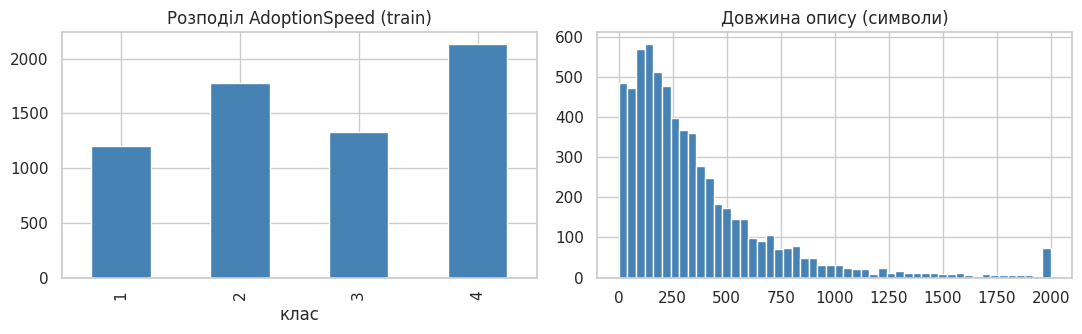

{1: 18.6, 2: 27.6, 3: 20.6, 4: 33.2}
порожніх описів у train: 0.001


In [15]:
# Розподіл класів і базова статистика
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
train[TARGET].value_counts().sort_index().plot.bar(ax=ax[0], color='steelblue')
ax[0].set_title('Розподіл AdoptionSpeed (train)'); ax[0].set_xlabel('клас')
train[TEXT_COL].str.len().clip(upper=2000).hist(bins=50, ax=ax[1], color='steelblue')
ax[1].set_title('Довжина опису (символи)')
plt.tight_layout(); plt.show()
print((train[TARGET].value_counts(normalize=True).sort_index()*100).round(1).to_dict())
print('порожніх описів у train:', (train[TEXT_COL].str.strip()=='').mean().round(3))

### Мапінг фото ↔ PetID

Фото іменовані як `<PetID>-<n>.jpg`. Будуємо словник за префіксом файлу й для кожної тварини шукаємо фото спочатку за «сирим» ID, потім за ID, доповненим нулями до 9 символів. Зайві файли в `images/test/` (тварини, яких немає в `test.csv`) ігноруємо.

In [16]:
img_files = sorted(glob.glob(str(INPUT / '**' / '*.jpg'), recursive=True))
print('всього jpg:', len(img_files))

by_prefix = defaultdict(list)
for p in img_files:
    stem = Path(p).stem
    pid = stem.rsplit('-', 1)[0]
    by_prefix[pid].append(p)

def photo_order(p):
    m = re.search(r'-(\d+)\.jpg$', p)
    return int(m.group(1)) if m else 0

def lookup_photos(pid):
    for key in (pid, pid.zfill(9)):
        if key in by_prefix:
            return sorted(by_prefix[key], key=photo_order)
    return []

train['photos'] = train.PetID.map(lookup_photos)
test['photos']  = test.PetID.map(lookup_photos)
train['n_photos'] = train.photos.str.len(); test['n_photos'] = test.photos.str.len()
print('train без фото:', (train.n_photos==0).sum(), '| test без фото:', (test.n_photos==0).sum())
print('фото на тварину (train):', train.n_photos.describe()[['mean','50%','max']].round(2).to_dict())

# Єдиний список усіх фото, що належать тваринам з CSV
all_photos = [p for lst in pd.concat([train.photos, test.photos]) for p in lst]
all_photos = list(dict.fromkeys(all_photos))
photo_idx = {p: i for i, p in enumerate(all_photos)}
print('фото для енкодингу:', len(all_photos))

всього jpg: 37920
train без фото: 0 | test без фото: 0
фото на тварину (train): {'mean': 4.43, '50%': 4.0, 'max': 30.0}
фото для енкодингу: 37849


## 2. Метрика і підбір порогів

QWK — з умови змагання (реалізація Ben Hamner). `OptimizedRounder` підбирає 3 пороги, які перетворюють неперервний прогноз регресії на класи 1–4 так, щоб максимізувати QWK на OOF-прогнозах.

In [17]:
def confusion_matrix_(rater_a, rater_b, min_rating=None, max_rating=None):
    assert(len(rater_a) == len(rater_b))
    if min_rating is None: min_rating = min(rater_a + rater_b)
    if max_rating is None: max_rating = max(rater_a + rater_b)
    num_ratings = int(max_rating - min_rating + 1)
    conf_mat = [[0 for i in range(num_ratings)] for j in range(num_ratings)]
    for a, b in zip(rater_a, rater_b):
        conf_mat[a - min_rating][b - min_rating] += 1
    return conf_mat

def histogram_(ratings, min_rating=None, max_rating=None):
    if min_rating is None: min_rating = min(ratings)
    if max_rating is None: max_rating = max(ratings)
    num_ratings = int(max_rating - min_rating + 1)
    hist_ratings = [0 for x in range(num_ratings)]
    for r in ratings:
        hist_ratings[r - min_rating] += 1
    return hist_ratings

def quadratic_weighted_kappa(y, y_pred):
    rater_a = np.array(y, dtype=int); rater_b = np.array(y_pred, dtype=int)
    assert(len(rater_a) == len(rater_b))
    min_rating = min(min(rater_a), min(rater_b)); max_rating = max(max(rater_a), max(rater_b))
    conf_mat = confusion_matrix_(list(rater_a), list(rater_b), min_rating, max_rating)
    num_ratings = len(conf_mat); num_scored_items = float(len(rater_a))
    hist_rater_a = histogram_(list(rater_a), min_rating, max_rating)
    hist_rater_b = histogram_(list(rater_b), min_rating, max_rating)
    numerator = 0.0; denominator = 0.0
    for i in range(num_ratings):
        for j in range(num_ratings):
            expected_count = (hist_rater_a[i] * hist_rater_b[j] / num_scored_items)
            d = pow(i - j, 2.0) / pow(num_ratings - 1, 2.0)
            numerator += d * conf_mat[i][j] / num_scored_items
            denominator += d * expected_count / num_scored_items
    return (1.0 - numerator / denominator)

class OptimizedRounder:
    '''Підбір порогів для перетворення регресійного прогнозу в класи 1..4 під QWK.'''
    def __init__(self, init=(1.5, 2.5, 3.5)):
        self.coef_ = np.array(init, dtype=float)
    @staticmethod
    def _apply(pred, coef):
        return 1 + np.digitize(pred, np.sort(coef))
    def _loss(self, coef, pred, y):
        return -quadratic_weighted_kappa(y, self._apply(pred, coef))
    def fit(self, pred, y):
        best = None
        for init in [self.coef_, np.quantile(pred, np.cumsum(np.bincount(y)[1:4]) / len(y))]:
            res = minimize(self._loss, init, args=(pred, y), method='nelder-mead',
                           options={'xatol': 1e-4, 'maxiter': 2000})
            if best is None or res.fun < best.fun: best = res
        self.coef_ = np.sort(best.x); return self
    def predict(self, pred, coef=None):
        return self._apply(pred, self.coef_ if coef is None else coef)

def qwk_from_regression(pred_oof, y):
    r = OptimizedRounder().fit(pred_oof, y)
    return quadratic_weighted_kappa(y, r.predict(pred_oof)), r.coef_

# Фіксовані фолди для всіх моделей (стратифіковані, без групування — train/test розбиті випадково,
# тому майже-дублікати присутні в тій самій пропорції і у валідації, і в test)
y = train[TARGET].values
folds = np.zeros(len(train), dtype=int)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for f, (_, va) in enumerate(skf.split(train, y)): folds[va] = f

results = {}  # назва кроку -> OOF QWK
def log_result(name, oof_pred):
    s, coef = qwk_from_regression(oof_pred, y)
    results[name] = round(s, 4)
    print(f'{name:45s} OOF QWK = {s:.4f}   пороги = {np.round(coef, 3)}')
    return s

## 3. Ембедінги фото: CLIP ViT-L/14 + SigLIP2

Обидва енкодери заморожені. Донавчання на цих даних не варте часу (студенти, які пробували, отримали +0.002–0.003 QWK за ~8 GPU-годин). Натомість використовуємо два різних енкодери: вони навчались на різних даних і різних лоссах, тож їхні помилки частково не корелюють, і стекінг бере від кожного сильне.

Один прохід по всіх фото обох вибірок, результат кешується в `.npy`.

In [18]:
import open_clip

class PhotoDS(Dataset):
    def __init__(self, paths, preprocess):
        self.paths = paths; self.pp = preprocess
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        try:
            img = Image.open(self.paths[i]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224))
        return self.pp(img), i

@torch.no_grad()
def encode_images(model, preprocess, paths, bs=64, name='enc'):
    out_path = CACHE / f'{name}_img.npy'
    if out_path.exists():
        print('кеш:', out_path); return np.load(out_path)
    dl = DataLoader(PhotoDS(paths, preprocess), batch_size=bs, num_workers=4, pin_memory=True)
    feats = []
    model.eval()
    for x, _ in tqdm(dl, desc=name):
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(DEVICE=='cuda')):
            f = model.encode_image(x.to(DEVICE, non_blocking=True))
        feats.append(torch.nn.functional.normalize(f.float(), dim=-1).cpu().numpy())
    feats = np.concatenate(feats).astype(np.float32)
    np.save(out_path, feats); return feats

ENCODERS = {
    'clip':   dict(model='ViT-L-14', pretrained='datacomp_xl_s13b_b90k', bs=128),
    'siglip': dict(model='ViT-SO400M-16-SigLIP2-384', pretrained='webli', bs=48,
                   fallback=('ViT-SO400M-14-SigLIP-384', 'webli')),  # якщо у встановленій open_clip ще немає SigLIP2
}
img_emb = {}
models = {}
for name, cfg in ENCODERS.items():
    t0 = time.time()
    try:
        model, _, preprocess = open_clip.create_model_and_transforms(cfg['model'], pretrained=cfg['pretrained'])
    except Exception as e:
        print(f'{cfg["model"]} недоступний ({e}); використовую {cfg["fallback"][0]}')
        model, _, preprocess = open_clip.create_model_and_transforms(*cfg['fallback'])
    model = model.to(DEVICE)
    img_emb[name] = encode_images(model, preprocess, all_photos, bs=cfg['bs'], name=name)
    print(name, img_emb[name].shape, f'{(time.time()-t0)/60:.1f} хв')
    if name == 'clip':
        models['clip'] = model   # потрібен далі для текстів і zero-shot
    else:
        del model; gc.collect(); torch.cuda.empty_cache()

open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.71GB            

open_clip_pytorch_model.bin: downloading bytes:           |  0.00B            

clip:   0%|          | 0/296 [00:00<?, ?it/s]

clip (37849, 768) 6.9 хв


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B / 4.54GB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

siglip:   0%|          | 0/789 [00:00<?, ?it/s]

siglip (37849, 1152) 24.3 хв


### Агрегація по тварині та метадані фото

Для кожної тварини — середнє по всіх фото і ембедінг першого фото (перше фото — головне в оголошенні). Тварини без фото отримують середній ембедінг train і прапорець `no_photo`. Метадані (розмір файлу, розміри першого фото) несподівано корелюють з таргетом — ймовірно, це слід джерела/періоду оголошення.

In [19]:
def aggregate(df, emb):
    d = emb.shape[1]
    mean_, first_ = np.zeros((len(df), d), np.float32), np.zeros((len(df), d), np.float32)
    has = np.zeros(len(df), bool)
    for i, lst in enumerate(df.photos):
        if lst:
            idx = [photo_idx[p] for p in lst]
            mean_[i] = emb[idx].mean(0); first_[i] = emb[idx[0]]; has[i] = True
    return mean_, first_, has

pet_emb = {}
for name in img_emb:
    tr = aggregate(train, img_emb[name]); te = aggregate(test, img_emb[name])
    fill_mean, fill_first = tr[0][tr[2]].mean(0), tr[1][tr[2]].mean(0)
    for arr, has in ((tr, tr[2]), (te, te[2])):
        arr[0][~has] = fill_mean; arr[1][~has] = fill_first
    pet_emb[name] = dict(train_mean=tr[0], train_first=tr[1], test_mean=te[0], test_first=te[1])

def photo_meta(df):
    rows = []
    for lst in tqdm(df.photos, desc='meta'):
        if not lst:
            rows.append([0, 0, 0, 0, 0, 1]); continue
        sizes = [os.path.getsize(p) for p in lst]
        try:
            with Image.open(lst[0]) as im: w, h = im.size
        except Exception: w, h = 0, 0
        rows.append([sizes[0], np.mean(sizes), w, h, w / max(h, 1), 0])
    return pd.DataFrame(rows, columns=['img_size_first', 'img_size_mean', 'img_w', 'img_h', 'img_ratio', 'no_photo'])

meta_tr, meta_te = photo_meta(train), photo_meta(test)
meta_tr['n_photos'] = train.n_photos.values; meta_te['n_photos'] = test.n_photos.values
print(meta_tr.corrwith(pd.Series(y)).round(3).to_dict())

meta:   0%|          | 0/6431 [00:00<?, ?it/s]

meta:   0%|          | 0/1891 [00:00<?, ?it/s]

{'img_size_first': 0.203, 'img_size_mean': 0.23, 'img_w': 0.059, 'img_h': 0.191, 'img_ratio': -0.088, 'no_photo': nan, 'n_photos': -0.052}


## 4. Текст: TF-IDF, текстовий енкодер CLIP, regex-ознаки

Описи — суміш англійської, малайської та китайської, з шаблонами від волонтерів. TF-IDF на словах (1–2-грами) + символьних n-грамах (2–5) добре ловить і шаблони, і мову. Regex-ознаки відновлюють частину табличних полів оригінального PetFinder (вік, тип, кількість тварин), які з цього датасету вилучені.

In [20]:
def clean_text(s):
    s = s.lower()
    s = re.sub(r'http\S+|www\.\S+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

txt_tr = train[TEXT_COL].map(clean_text); txt_te = test[TEXT_COL].map(clean_text)
txt_all = pd.concat([txt_tr, txt_te]).values

word_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=60000, sublinear_tf=True)
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=3, max_features=80000, sublinear_tf=True)
X_tfidf_all = sparse.hstack([word_vec.fit_transform(txt_all), char_vec.fit_transform(txt_all)]).tocsr()
X_tfidf_tr, X_tfidf_te = X_tfidf_all[:len(train)], X_tfidf_all[len(train):]
print('tfidf:', X_tfidf_tr.shape)

tfidf: (6431, 111805)


In [21]:
NUM = {'one':1,'two':2,'three':3,'four':4,'five':5,'six':6,'seven':7,'eight':8,'nine':9,'ten':10,'satu':1,'dua':2,'tiga':3,'empat':4,'lima':5}
def num_(s):
    s = s.strip(); return float(s) if re.match(r'^[\d.]+$', s) else NUM.get(s, np.nan)

AGE_RE = re.compile(r'(\d+(?:\.\d+)?|one|two|three|four|five|six|seven|eight|nine|ten|satu|dua|tiga|empat|lima)\s*(?:\+|-|to|hingga)?\s*(?:\d+\s*)?(months?|mths?|mos?\b|bulan|years?|yrs?|tahun|weeks?|wks?|minggu|days?|hari)')
def age_months(s):
    best = np.nan
    for n, unit in AGE_RE.findall(s):
        v = num_(n)
        if np.isnan(v): continue
        if unit.startswith(('y', 'tahun')): v *= 12
        elif unit.startswith(('w', 'minggu')): v /= 4.3
        elif unit.startswith(('d', 'hari')): v /= 30
        if v <= 240 and (np.isnan(best) or v < best): best = v
    return best

def text_feats(s_raw):
    s = s_raw.lower()
    return dict(
        txt_len=len(s), txt_words=len(s.split()), txt_empty=int(len(s.strip()) == 0),
        age_m=age_months(s),
        is_baby=int(bool(re.search(r'\b(kitten|kittens|puppy|puppies|anak kucing|anak anjing|newborn)\b', s))),
        is_cat=int(bool(re.search(r'\b(cat|cats|kitten|kittens|kucing|meow)\b', s))),
        is_dog=int(bool(re.search(r'\b(dog|dogs|puppy|puppies|anjing|woof)\b', s))),
        mixed=int(bool(re.search(r'\b(mix|mixed|campur|kacukan|domestic)\b', s))),
        vaccin=int('vaccin' in s), neuter=int(bool(re.search(r'neuter|spay|sterili|mandul', s))),
        dewormed=int('deworm' in s), fee=int(bool(re.search(r'\b(rm\s?\d+|fee|adoption fee|yuran)\b', s))),
        multi=int(bool(re.search(r'\b(siblings|litter|brothers|sisters|them|they|their)\b', s))),
        n_digits=sum(ch.isdigit() for ch in s), has_phone=int(bool(re.search(r'\d{3}[\s-]?\d{3,4}[\s-]?\d{3,4}', s))),
        n_excl=s.count('!'), upper_ratio=sum(ch.isupper() for ch in s_raw) / max(len(s_raw), 1),
        has_chinese=int(bool(re.search(r'[一-鿿]', s))),
        has_malay=int(bool(re.search(r'\b(dan|untuk|sangat|yang|kucing|anjing|bulan|tahun)\b', s))),
    )

tf_tr = pd.DataFrame([text_feats(s) for s in train[TEXT_COL]])
tf_te = pd.DataFrame([text_feats(s) for s in test[TEXT_COL]])
print('вік знайдено у', round(tf_tr.age_m.notna().mean()*100, 1), '% описів')
print(pd.DataFrame({'age_m': tf_tr.age_m, 'y': y}).dropna().assign(bin=lambda d: pd.cut(d.age_m, [0, 2, 4, 6, 12, 36, 240]))
      .groupby('bin', observed=True).y.agg(['mean', 'size']).round(2))

вік знайдено у 26.8 % описів
           mean  size
bin                  
(0, 2]     2.38   946
(2, 4]     2.71   249
(4, 6]     2.64   207
(6, 12]    3.07   134
(12, 36]   2.87   112
(36, 240]  2.81    75


In [22]:
# Текстові ембедінги CLIP (ліміт 77 токенів — беремо початок опису)
@torch.no_grad()
def encode_texts(model, tokenizer, texts, bs=256):
    out = []
    for i in tqdm(range(0, len(texts), bs), desc='clip text'):
        tok = tokenizer(list(texts[i:i+bs])).to(DEVICE)
        f = model.encode_text(tok).float()
        out.append(torch.nn.functional.normalize(f, dim=-1).cpu().numpy())
    return np.concatenate(out).astype(np.float32)

clip_tok = open_clip.get_tokenizer(ENCODERS['clip']['model'])
txt_emb_all = encode_texts(models['clip'], clip_tok, txt_all)
txt_emb_tr, txt_emb_te = txt_emb_all[:len(train)], txt_emb_all[len(train):]
print(txt_emb_tr.shape)

clip text:   0%|          | 0/33 [00:00<?, ?it/s]

(6431, 768)


## 5. Zero-shot ознаки CLIP

Групи промптів; усередині групи — softmax по косинусних схожостях фото з текстами. Так ми «відновлюємо» вік, породу, кількість тварин, присутність людини, оточення й якість фото — ознаки, яких у датасеті немає, але які в оригінальному змаганні були серед найсильніших. Агрегуємо по тварині середнім і для першого фото.

In [23]:
ZS_GROUPS = {
    'type':    ['a photo of a cat', 'a photo of a dog'],
    'age':     ['a photo of a newborn kitten or puppy', 'a photo of a young kitten or puppy',
                'a photo of an adult cat or dog', 'a photo of an old senior cat or dog'],
    'breed':   ['a photo of a purebred pedigree cat or dog', 'a photo of a mixed breed stray cat or dog'],
    'count':   ['a photo of a single animal', 'a photo of several animals together'],
    'human':   ['a photo of a pet with a person', 'a photo of a pet with no people'],
    'place':   ['a photo of a pet in a cage', 'a photo of a pet inside a home', 'a photo of a pet outdoors on the street'],
    'quality': ['a sharp high quality photo', 'a blurry low quality photo', 'a dark photo'],
    'cute':    ['a cute fluffy healthy pet', 'a sick injured dirty animal'],
}
@torch.no_grad()
def zero_shot(model, tokenizer, img_feats):
    cols, feats = [], []
    for g, prompts in ZS_GROUPS.items():
        t = model.encode_text(tokenizer(prompts).to(DEVICE)).float()
        t = torch.nn.functional.normalize(t, dim=-1).cpu().numpy()
        logits = 100.0 * img_feats @ t.T
        p = np.exp(logits - logits.max(1, keepdims=True)); p /= p.sum(1, keepdims=True)
        feats.append(p); cols += [f'zs_{g}_{i}' for i in range(len(prompts))]
    return pd.DataFrame(np.concatenate(feats, 1), columns=cols)

zs_img = zero_shot(models['clip'], clip_tok, img_emb['clip'])

def agg_zs(df):
    mean_rows, first_rows = [], []
    for lst in df.photos:
        if lst:
            idx = [photo_idx[p] for p in lst]
            mean_rows.append(zs_img.iloc[idx].mean(0).values); first_rows.append(zs_img.iloc[idx[0]].values)
        else:
            mean_rows.append(np.full(zs_img.shape[1], np.nan)); first_rows.append(np.full(zs_img.shape[1], np.nan))
    m = pd.DataFrame(mean_rows, columns=[c + '_mean' for c in zs_img.columns])
    f = pd.DataFrame(first_rows, columns=[c + '_first' for c in zs_img.columns])
    return pd.concat([m, f], axis=1)

zs_tr, zs_te = agg_zs(train), agg_zs(test)
print(zs_tr.corrwith(pd.Series(y)).abs().sort_values(ascending=False).head(8).round(3))
del models; gc.collect(); torch.cuda.empty_cache()

zs_cute_0_mean     0.348
zs_cute_1_mean     0.348
zs_age_2_mean      0.339
zs_age_1_mean      0.333
zs_age_2_first     0.331
zs_age_1_first     0.328
zs_cute_0_first    0.313
zs_cute_1_first    0.313
dtype: float64


## 6. Моделі першого рівня: Ridge на кожному представленні

Кожна модель дає out-of-fold прогноз (OOF) для train і прогноз для test (середнє по 5 фолдових моделях). OOF-прогнози далі стають ознаками для моделі 2-го рівня — так стекінг не бачить «підглянутих» міток.

In [24]:
def ridge_oof(X_tr, X_te, alpha, name):
    oof = np.zeros(len(train)); te = np.zeros(X_te.shape[0])
    for f in range(5):
        tr_idx, va_idx = np.where(folds != f)[0], np.where(folds == f)[0]
        m = Ridge(alpha=alpha).fit(X_tr[tr_idx], y[tr_idx])
        oof[va_idx] = m.predict(X_tr[va_idx]); te += m.predict(X_te) / 5
    log_result(name, oof)
    return oof, te

L1 = {}  # назва -> (oof, test)
L1['ridge_clip']   = ridge_oof(np.hstack([pet_emb['clip']['train_mean'], pet_emb['clip']['train_first']]),
                               np.hstack([pet_emb['clip']['test_mean'],  pet_emb['clip']['test_first']]), 3.0, 'Ridge CLIP (mean+first)')
L1['ridge_siglip'] = ridge_oof(np.hstack([pet_emb['siglip']['train_mean'], pet_emb['siglip']['train_first']]),
                               np.hstack([pet_emb['siglip']['test_mean'],  pet_emb['siglip']['test_first']]), 3.0, 'Ridge SigLIP2 (mean+first)')
L1['ridge_tfidf']  = ridge_oof(X_tfidf_tr, X_tfidf_te, 3.0, 'Ridge TF-IDF')
L1['ridge_cliptxt']= ridge_oof(txt_emb_tr, txt_emb_te, 3.0, 'Ridge CLIP text')

Ridge CLIP (mean+first)                       OOF QWK = 0.5875   пороги = [2.1   2.515 3.115]
Ridge SigLIP2 (mean+first)                    OOF QWK = 0.5987   пороги = [1.945 2.528 3.067]
Ridge TF-IDF                                  OOF QWK = 0.3693   пороги = [2.309 2.643 2.969]
Ridge CLIP text                               OOF QWK = 0.3100   пороги = [2.226 2.659 3.004]


### Страховий сабмішн №1

Ще до стекінгу формуємо сабмішн із простого бленду двох Ridge по фото — він уже далеко за порогом 0.5. Пороги — з OOF цього ж бленду.

In [25]:
def make_submission(pred_test_cont, coef, path):
    cls = 1 + np.digitize(pred_test_cont, np.sort(coef))
    sub = pd.DataFrame({'PetID': test.PetID.values, TARGET: cls.astype(int)})
    assert sub.PetID.is_unique and len(sub) == len(test) and sub[TARGET].between(1, 4).all()
    sub.to_csv(path, index=False)
    print(path, sub[TARGET].value_counts(normalize=True).sort_index().round(3).to_dict())
    return sub

blend_oof = (L1['ridge_clip'][0] + L1['ridge_siglip'][0]) / 2
blend_te  = (L1['ridge_clip'][1] + L1['ridge_siglip'][1]) / 2
s, coef = qwk_from_regression(blend_oof, y); results['Blend Ridge CLIP+SigLIP2'] = round(s, 4)
print('blend OOF QWK:', round(s, 4))
_ = make_submission(blend_te, coef, WORK / 'submission_safe.csv')

blend OOF QWK: 0.6008
/kaggle/working/submission_safe.csv {1: 0.231, 2: 0.209, 3: 0.191, 4: 0.369}


## 7. kNN-ознаки по таргету схожих оголошень

Близько 12 % оголошень — майже дублікати (той самий волонтер, той самий шаблон, ті самі фото), і всередині таких груп таргет майже збігається. Для кожної тварини беремо k найближчих сусідів **з інших фолдів** (для test — з усього train) і рахуємо зважене середнє їхнього таргету (вага sim⁴) та максимальну схожість. Витоку немає: рядок ніколи не бачить міток свого фолду.

In [26]:
def knn_target_feats(X_tr, X_te, name, ks=(5, 20), sparse_input=False):
    def sims(A, B):
        S = A @ B.T
        return S.toarray() if sparse_input else S
    def feats_from(S, y_ref):
        out = {}
        order = np.argsort(-S, axis=1)
        for k in ks:
            nn = order[:, :k]; s = np.take_along_axis(S, nn, 1).clip(0, 1); w = s ** 4 + 1e-6
            out[f'knn_{name}_mean{k}'] = (w * y_ref[nn]).sum(1) / w.sum(1)
        out[f'knn_{name}_simmax'] = S.max(1)
        out[f'knn_{name}_top1'] = y_ref[order[:, 0]]
        return pd.DataFrame(out)
    oof = []
    for f in range(5):
        tr_idx, va_idx = np.where(folds != f)[0], np.where(folds == f)[0]
        d = feats_from(sims(X_tr[va_idx], X_tr[tr_idx]), y[tr_idx]); d.index = va_idx; oof.append(d)
    oof = pd.concat(oof).sort_index()
    te = feats_from(sims(X_te, X_tr), y)
    return oof, te

knn_clip_tr, knn_clip_te = knn_target_feats(pet_emb['clip']['train_mean'], pet_emb['clip']['test_mean'], 'clip')
knn_sig_tr,  knn_sig_te  = knn_target_feats(pet_emb['siglip']['train_mean'], pet_emb['siglip']['test_mean'], 'siglip')
knn_txt_tr,  knn_txt_te  = knn_target_feats(normalize(X_tfidf_tr), normalize(X_tfidf_te), 'tfidf', sparse_input=True)
knn_tr = pd.concat([knn_clip_tr, knn_sig_tr, knn_txt_tr], axis=1); knn_te = pd.concat([knn_clip_te, knn_sig_te, knn_txt_te], axis=1)
print(knn_tr.corrwith(pd.Series(y)).round(3).sort_values(ascending=False).head(6))
print('частка test з «двійником» (sim>0.95 по CLIP):', (knn_te.knn_clip_simmax > 0.95).mean().round(3))

knn_clip_mean20      0.545
knn_siglip_mean20    0.538
knn_siglip_mean5     0.490
knn_clip_mean5       0.490
knn_siglip_top1      0.362
knn_tfidf_mean20     0.362
dtype: float64
частка test з «двійником» (sim>0.95 по CLIP): 0.004


## 8. Стекінг: LightGBM на OOF-прогнозах і ознаках

Модель 2-го рівня — регресія LightGBM (L2) з помірною регуляризацією; 3 сіди усереднюємо. Ознаки: 4 OOF-прогнози Ridge, kNN-ознаки, zero-shot, regex-ознаки тексту, метадані фото.

In [27]:
def build_X(l1_part, knn, zs, tf, meta):
    X = pd.concat([pd.DataFrame({k: v[l1_part] for k, v in L1.items()}), knn, zs, tf, meta], axis=1)
    X.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in X.columns]
    return X

X_tr = build_X(0, knn_tr, zs_tr, tf_tr, meta_tr); X_te = build_X(1, knn_te, zs_te, tf_te, meta_te)
print('ознак у стеку:', X_tr.shape[1])

LGB_PARAMS = dict(objective='regression', learning_rate=0.03, num_leaves=31, min_child_samples=30,
                  feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0, verbosity=-1)
SEEDS = [0, 1, 2]

oof_stack = np.zeros(len(train)); te_stack = np.zeros(len(test)); best_iters = []; importances = np.zeros(X_tr.shape[1])
for seed in SEEDS:
    for f in range(5):
        tr_idx, va_idx = np.where(folds != f)[0], np.where(folds == f)[0]
        m = lgb.train({**LGB_PARAMS, 'seed': seed}, lgb.Dataset(X_tr.iloc[tr_idx], y[tr_idx]), num_boost_round=3000,
                      valid_sets=[lgb.Dataset(X_tr.iloc[va_idx], y[va_idx])],
                      callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_stack[va_idx] += m.predict(X_tr.iloc[va_idx], num_iteration=m.best_iteration) / len(SEEDS)
        te_stack += m.predict(X_te, num_iteration=m.best_iteration) / (5 * len(SEEDS))
        best_iters.append(m.best_iteration); importances += m.feature_importance('gain')
print('best_iter mean:', int(np.mean(best_iters)))
stack_qwk = log_result('Stack LightGBM (L1 + kNN + zero-shot + text + meta)', oof_stack)

ознак у стеку: 82
best_iter mean: 115
Stack LightGBM (L1 + kNN + zero-shot + text + meta) OOF QWK = 0.6182   пороги = [1.919 2.547 3.117]


QWK з nested-порогами: 0.6112


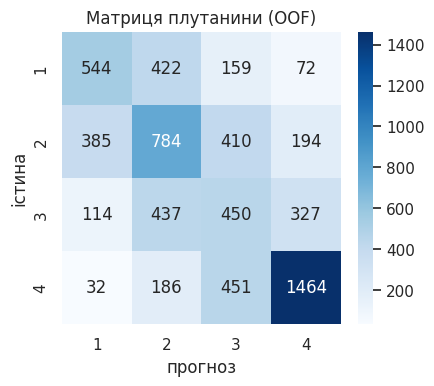

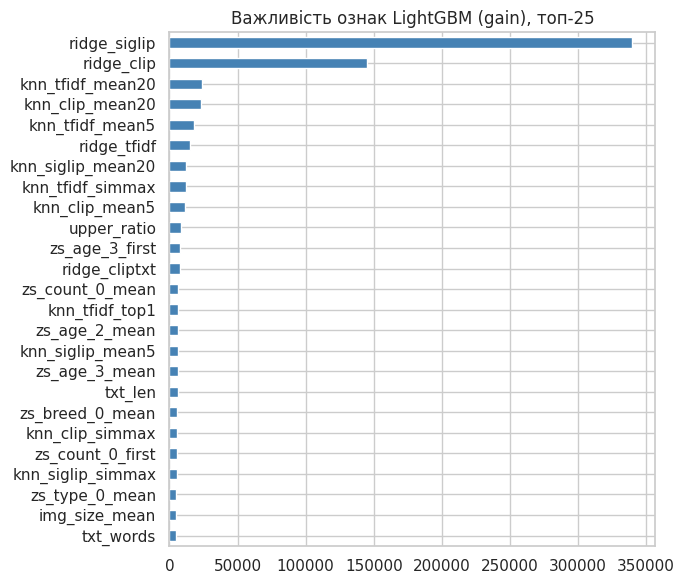

{'фото (L1 Ridge)': '57.2%', 'текст (L1 Ridge)': '2.7%', 'kNN': '15.1%', 'zero-shot': '19.6%', 'інше': '5.5%'}


In [28]:
# Чесна оцінка порогів: підбір на 4 фолдах, застосування до 5-го (щоб оцінка QWK не була оптимістичною)
honest = np.zeros(len(train), int)
for f in range(5):
    tr_idx, va_idx = np.where(folds != f)[0], np.where(folds == f)[0]
    r = OptimizedRounder().fit(oof_stack[tr_idx], y[tr_idx]); honest[va_idx] = r.predict(oof_stack[va_idx])
print('QWK з nested-порогами:', round(quadratic_weighted_kappa(y, honest), 4))

rounder = OptimizedRounder().fit(oof_stack, y)
oof_cls = rounder.predict(oof_stack)
cm = pd.crosstab(pd.Series(y, name='істина'), pd.Series(oof_cls, name='прогноз'))
plt.figure(figsize=(4.5, 3.8)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title('Матриця плутанини (OOF)'); plt.show()

imp = pd.Series(importances, index=X_tr.columns).sort_values(ascending=False)
plt.figure(figsize=(7, 6)); imp.head(25)[::-1].plot.barh(color='steelblue'); plt.title('Важливість ознак LightGBM (gain), топ-25'); plt.tight_layout(); plt.show()
groups = {'фото (L1 Ridge)': ['ridge_clip', 'ridge_siglip'], 'текст (L1 Ridge)': ['ridge_tfidf', 'ridge_cliptxt']}
share = {g: imp[cols].sum() for g, cols in groups.items()}
share['kNN'] = imp[[c for c in imp.index if c.startswith('knn_')]].sum()
share['zero-shot'] = imp[[c for c in imp.index if c.startswith('zs_')]].sum()
share['інше'] = imp.sum() - sum(share.values())
print({k: f'{v / imp.sum() * 100:.1f}%' for k, v in share.items()})

## 9. Фінальна модель і сабмішн

Перенавчаємо модель 2-го рівня на всьому train (кількість раундів = середнє best_iter з CV × 1.15, бо даних на 25 % більше), пороги беремо з OOF. Ознаки для test уже обчислені з усього train (kNN) і усереднених фолдових Ridge-моделей.

In [29]:
n_rounds = int(np.mean(best_iters) * 1.15)
te_full = np.zeros(len(test))
for seed in SEEDS:
    m = lgb.train({**LGB_PARAMS, 'seed': seed}, lgb.Dataset(X_tr, y), num_boost_round=n_rounds)
    te_full += m.predict(X_te) / len(SEEDS)
# Бленд: повна модель + усереднені фолдові (стабільніше, ніж будь-що одне)
te_final = 0.5 * te_full + 0.5 * te_stack
sub = make_submission(te_final, rounder.coef_, WORK / 'submission.csv')
display(sub.head())
print('розподіл класів у train:', train[TARGET].value_counts(normalize=True).sort_index().round(3).to_dict())

/kaggle/working/submission.csv {1: 0.178, 2: 0.245, 3: 0.222, 4: 0.355}


,PetID,AdoptionSpeed
0,6697a7f62,3
1,23b64fe21,2
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,4


розподіл класів у train: {1: 0.186, 2: 0.276, 3: 0.206, 4: 0.332}


## 10. Підсумок експериментів

In [30]:
res = pd.DataFrame.from_dict(results, orient='index', columns=['OOF QWK'])
display(res)

,OOF QWK
Ridge CLIP (mean+first),0.5875
Ridge SigLIP2 (mean+first),0.5987
Ridge TF-IDF,0.3693
Ridge CLIP text,0.3100
Blend Ridge CLIP+SigLIP2,0.6008
Stack LightGBM (L1 + kNN + zero-shot + text + meta),0.6182


### Висновки

- **Фото дають основний сигнал.** Ridge на заморожених ембедінгах CLIP і SigLIP2 — близько 0.58–0.60 QWK кожен; текст (TF-IDF / CLIP text) — приблизно вдвічі менше. Два енкодери разом у стеку кращі за кожен окремо, бо їхні помилки не збігаються.
- **Схожі оголошення — сильна ознака.** kNN-середнє таргету найближчих сусідів (OOF) підтягує результат, бо значна частина оголошень шаблонна й має однакову швидкість адопції.
- **Порядкова метрика → регресія + пороги.** Підбір порогів дає значно більше, ніж звичайне округлення або argmax multiclass.
- **Zero-shot CLIP** частково відновлює вилучені табличні ознаки (вік, порода, кількість тварин) без жодного навчання.
- Що не входило через час і підтверджено іншими учасниками як мало корисне: донавчання енкодерів фото, fine-tuning DeBERTa (≈ рівень TF-IDF), PCA/SVD ембедінгів, LLM-екстракція фактів з описів.

**Файли:** `submission.csv` (фінал, стекінг) і `submission_safe.csv` (бленд Ridge по фото).